# Task 3: MNIST 手寫數字分類 — CNN
### Modeling · Optimization · Handling Class Imbalance

**目標：** 透過 `torchvision` 下載 MNIST 資料集，設計、實作並評估一個卷積神經網路（CNN）進行數字分類。需要著重在：**建模（Modeling）**、**優化（Optimization）**、以及**類別不平衡處理（Class Imbalance）** 等的處理。

**後續流程**

1. **EDA** — 載入 MNIST，探索影像與各數字類別分布。其中有 training data 60000筆 ＆ testing data 10000筆
2. **資料切分** — training data 中依各類別的比例下做 8:2 的切分切成 training set & validation set ； validation set 會用來做作為訓練模型時的評估基準。
3. **類別不平衡** — MNIST 原始資料幾乎是平衡的，因此我們**人為製造**一個長尾（long-tailed）訓練集（指數衰減、不平衡比 100:1），先製造出真實世界常見的難題，再示範如何解決。
4. **建模** — 以 ImageNet 預訓練的 **ResNet-18 做遷移學習（transfer learning）**：資料端適配輸入格式（放大、三通道化、ImageNet 正規化），模型端只把分類頭換成 10 類，並說明微調（fine-tuning）策略。
5. **優化** — AdamW + 差異化學習率（backbone 小步微調、新分類頭大步學習）、CosineAnnealingLR、early stopping，以及訓練曲線分析。
6. **實驗** — Baseline（一般 cross-entropy）vs. 類別加權 cross-entropy（weighted loss），在平衡的 test set 上以 per-class 指標、macro-F1 與 confusion matrix 進行對比。

## 1. Initilization 
匯入套件、設定全域隨機種子確保實驗可重現（reproducibility）、自動選擇運算裝置（Apple-Silicon MPS → CUDA → CPU 依序遞補），並統一整份 notebook 的繪圖風格。

In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from sklearn.metrics import (average_precision_score, balanced_accuracy_score,
                             confusion_matrix, f1_score, precision_recall_curve)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

# --- Reproducibility --------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# --- Device: Apple-Silicon MPS > CUDA > CPU ---------------------------------
device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

# --- Plotting style ----------------------------------------------------------
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"  # categorical series colors
VIOLET, MAGENTA = "#4a3aa7", "#e87ba4"
INK, INK_MUTED = "#1a1a19", "#6b6a63"                 # text colors
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": INK_MUTED,
    "axes.labelcolor": INK,
    "axes.grid": True,
    "grid.color": "#e8e7e0",
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "text.color": INK,
    "font.size": 11,
})

print(f"PyTorch {torch.__version__} | torchvision {torchvision.__version__}")
print(f"Device: {device}")

PyTorch 2.13.0 | torchvision 0.28.0
Device: mps


## 2. 載入 MNIST 資料集

依照 [PyTorch 官方文件](https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html)，`torchvision.datasets.MNIST` 會自動下載資料集：

- **60,000 張訓練影像** 與 **10,000 張測試影像**
- 28×28 像素、單通道（灰階）、10 個類別（數字 0–9）

這裡先載入原始資料（不套用 tensor transforms），因為本節只做資料探索；tensor 轉換與正規化屬於訓練 pipeline 的一部分，會在後面的章節定義。

In [2]:
DATA_DIR = "./data"

train_full = datasets.MNIST(root=DATA_DIR, train=True, download=True)
test_set = datasets.MNIST(root=DATA_DIR, train=False, download=True)

train_labels = train_full.targets.numpy()
test_labels = test_set.targets.numpy()

print(train_full)
print()
print(test_set)
print(f"\nImage size: {tuple(train_full.data.shape[1:])} | pixel dtype: {train_full.data.dtype}")

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train

Dataset MNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test

Image size: (28, 28) | pixel dtype: torch.uint8


## 3. 初步資料探索

### 3.1 影像樣本

抽樣觀看資料（training & testing 每個數字隨機抽 6 張訓練影像）,可以觀察到同一類別內的手寫風格差異很大（筆畫粗細、傾斜角度、字形）。

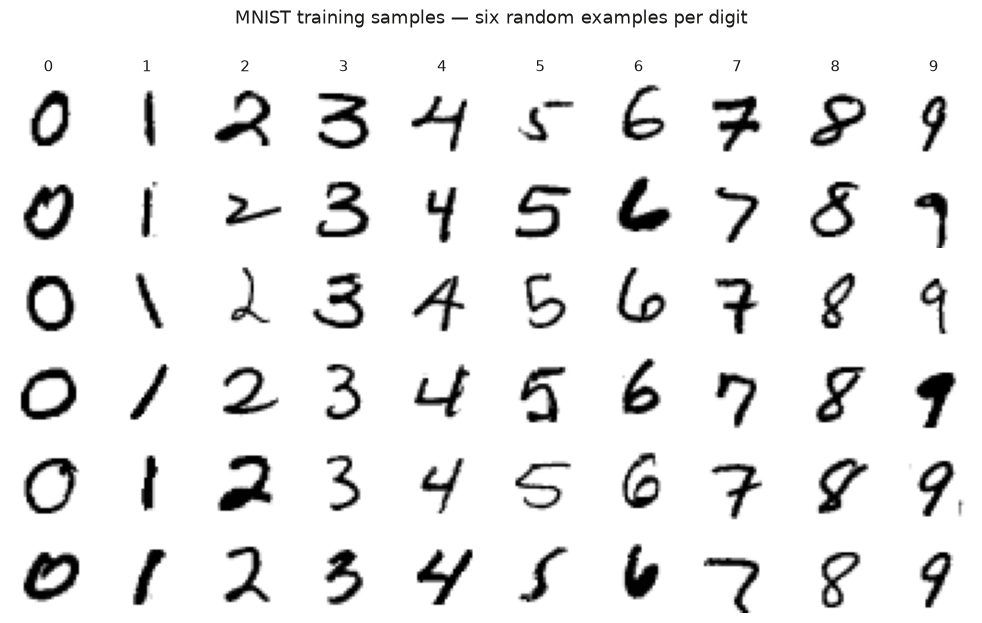

In [3]:
rng = np.random.default_rng(SEED)
n_examples = 6

fig, axes = plt.subplots(n_examples, 10, figsize=(10, 6.2))
for digit in range(10):
    idx = rng.choice(np.where(train_labels == digit)[0], size=n_examples, replace=False)
    for row in range(n_examples):
        ax = axes[row, digit]
        ax.imshow(train_full.data[idx[row]], cmap="gray_r")
        ax.set_axis_off()
        if row == 0:
            ax.set_title(str(digit), fontsize=11, color=INK)
fig.suptitle("MNIST training samples — six random examples per digit", y=1.0)
fig.tight_layout()
plt.show()

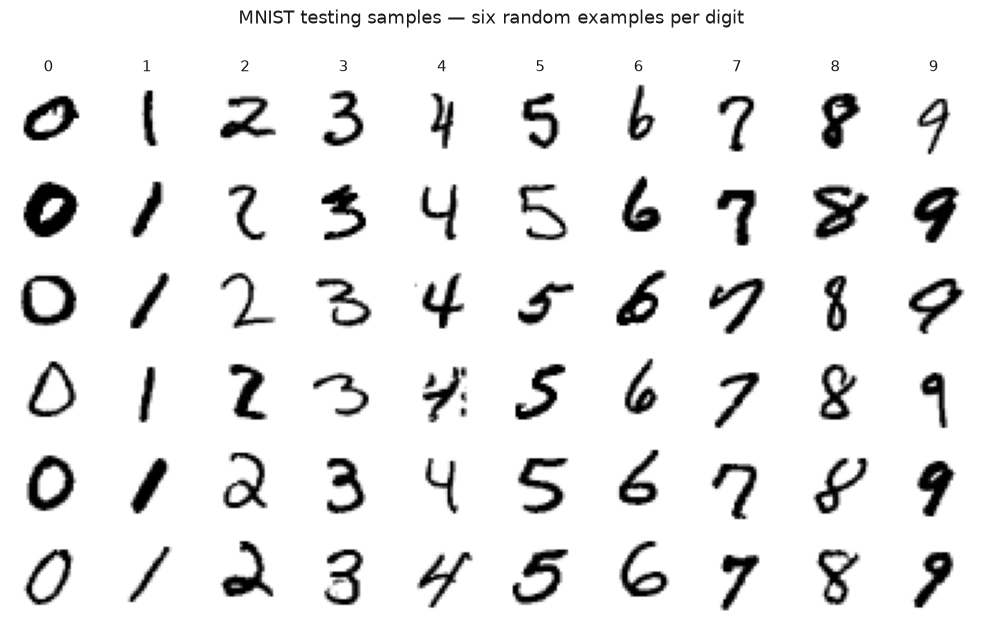

In [4]:
rng = np.random.default_rng(SEED)
n_examples = 6

fig, axes = plt.subplots(n_examples, 10, figsize=(10, 6.2))
for digit in range(10):
    idx = rng.choice(np.where(test_labels == digit)[0], size=n_examples, replace=False)
    for row in range(n_examples):
        ax = axes[row, digit]
        ax.imshow(test_set.data[idx[row]], cmap="gray_r")
        ax.set_axis_off()
        if row == 0:
            ax.set_title(str(digit), fontsize=11, color=INK)
fig.suptitle("MNIST testing samples — six random examples per digit", y=1.0)
fig.tight_layout()
plt.show()

### 3.2  確認 MNIST 資料集原始資料各個類別的分布佔比

在處理類別不平衡之前，應該先**量化**它的程度。下方的表格與長條圖顯示官方 train/test 兩個資料集中每個數字的影像數量。

,train_count,train_share_%,test_count,test_share_%
digit,,,,
0,5923,9.87,980,9.80
1,6742,11.24,1135,11.35
2,5958,9.93,1032,10.32
3,6131,10.22,1010,10.10
4,5842,9.74,982,9.82
5,5421,9.04,892,8.92
6,5918,9.86,958,9.58
7,6265,10.44,1028,10.28
8,5851,9.75,974,9.74


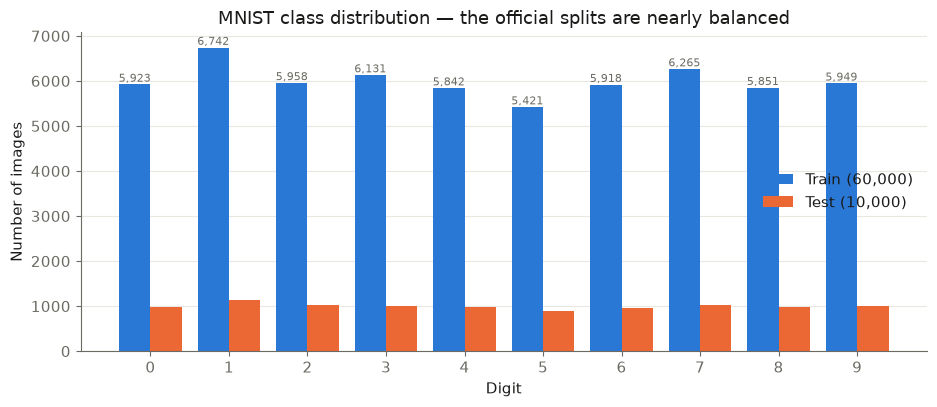

Train: min 5,421 (digit 5) | max 6,742 (digit 1) | imbalance ratio 1.24 : 1


In [5]:
classes = np.arange(10)
train_counts = np.bincount(train_labels, minlength=10)
test_counts = np.bincount(test_labels, minlength=10)

dist = pd.DataFrame({
    "train_count": train_counts,
    "train_share_%": (100 * train_counts / train_counts.sum()).round(2),
    "test_count": test_counts,
    "test_share_%": (100 * test_counts / test_counts.sum()).round(2),
}, index=pd.Index(classes, name="digit"))
display(dist)

x = np.arange(10)
w = 0.4
fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.bar(x - w / 2, train_counts, width=w, color=BLUE, label="Train (60,000)")
ax.bar(x + w / 2, test_counts, width=w, color=ORANGE, label="Test (10,000)")
for xi, c in zip(x, train_counts):
    ax.annotate(f"{c:,}", (xi - w / 2, c), ha="center", va="bottom",
                fontsize=8, color=INK_MUTED)
ax.set_xticks(x)
ax.set_xlabel("Digit")
ax.set_ylabel("Number of images")
ax.set_title("MNIST class distribution — the official splits are nearly balanced")
ax.legend(frameon=False)
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

print(f"Train: min {train_counts.min():,} (digit {train_counts.argmin()}) | "
      f"max {train_counts.max():,} (digit {train_counts.argmax()}) | "
      f"imbalance ratio {train_counts.max() / train_counts.min():.2f} : 1")

  MNIST 每個類別資料佔比差異不大,基本上是平衡的資料集。為了要在訓練的過程模擬資料不平衡的狀況,故在模型的訓練資料預計建構一個不平衡比 100 : 1 的長尾（long-tailed）訓練集，並以它進行所有後續實驗。

## 4. 分層 80/20 Train/Validation 切分

我們的資料策略使用三個角色明確分離的資料集：

| 資料集 | 大小 | 分布 | 用途 |
|-----|------|--------------|------|
| Training | 48,000（訓練池的 80%）| 長尾（第 5 節製造）| 擬合模型權重 |
| Validation | 12,000（訓練池的 20%）| 平衡 | 訓練模型時的評估 |
| Test（官方）| 10,000 | 平衡 | 只做最終評估——開發過程中絕不使用 |

兩個刻意的設計決策：

- **分層抽樣（stratified split）。** `stratify=train_labels` 讓切分後兩邊的類別比例維持一致，validation 指標在各類別之間才有可比性，之後的降採樣也能從已知的分布出發。
- **Validation 與 test 保持平衡。** 不平衡只施加在 80% 的訓練部分。在平衡的資料上評估，才能誠實地量測「不平衡訓練讓每個類別退化了多少」——如果評估資料也是長尾，少數類別的失敗會被整體高 accuracy 掩蓋掉。

In [6]:
train_idx, val_idx = train_test_split(
    np.arange(len(train_full)),
    test_size=0.2,
    random_state=SEED,
    stratify=train_labels,
)

y_train, y_val = train_labels[train_idx], train_labels[val_idx]

split_check = pd.DataFrame({
    "train_count": np.bincount(y_train, minlength=10),
    "train_share_%": (100 * np.bincount(y_train, minlength=10) / len(y_train)).round(2),
    "val_count": np.bincount(y_val, minlength=10),
    "val_share_%": (100 * np.bincount(y_val, minlength=10) / len(y_val)).round(2),
}, index=pd.Index(classes, name="digit"))

print(f"Training set:   {len(train_idx):,} images (80%)")
print(f"Validation set: {len(val_idx):,} images (20%)")
display(split_check)

# Stratification check: per-class shares must match between the two parts.
assert np.allclose(split_check["train_share_%"], split_check["val_share_%"], atol=0.05)
print("Stratification OK — per-class shares match between train and validation.")

Training set:   48,000 images (80%)
Validation set: 12,000 images (20%)


,train_count,train_share_%,val_count,val_share_%
digit,,,,
0,4738,9.87,1185,9.88
1,5394,11.24,1348,11.23
2,4766,9.93,1192,9.93
3,4905,10.22,1226,10.22
4,4674,9.74,1168,9.73
5,4337,9.04,1084,9.03
6,4734,9.86,1184,9.87
7,5012,10.44,1253,10.44
8,4681,9.75,1170,9.75


Stratification OK — per-class shares match between train and validation.


## 5. 製造長尾類別不平衡（Long-Tailed Imbalance）

真實世界的分類問題（製造業瑕疵檢測、詐欺偵測、罕見疾病診斷）常呈現長尾分布：少數幾個類別佔了絕大多數樣本，其餘類別非常稀少。我們依照長尾學習文獻的標準做法（Cui et al., 2019 的 long-tailed CIFAR 設定），對訓練集做**指數衰減降採樣**：

$$n_i = n_0 \cdot \mu^{\,i},\qquad \mu = \mathrm{IF}^{-1/9},\qquad \mathrm{IF}=100$$

- 數字 $i$ 保留 $n_i$ 張影像（$n_0$ 為數字 0 在訓練集中的全部樣本數）
- **不平衡比（imbalance factor, IF）= 100**：頭部類別（數字 0）約 4,700 張 → 尾部類別（數字 9）只剩約 47 張
- 降採樣**只施加在 training set**；validation 與 test 維持平衡（理由見第 4 節）

In [7]:
IMBALANCE_FACTOR = 100                     # 頭部類 / 尾部類 的樣本數比
DECAY = IMBALANCE_FACTOR ** (-1 / 9)       # 指數衰減係數 mu ~= 0.60

avail = np.bincount(y_train, minlength=10)
lt_counts = np.floor(avail[0] * DECAY ** classes).astype(int)

rng_lt = np.random.default_rng(SEED)
lt_train_idx = np.concatenate([
    rng_lt.choice(train_idx[y_train == c], size=lt_counts[c], replace=False)
    for c in classes
])
y_lt = train_labels[lt_train_idx]

lt_table = pd.DataFrame({
    "available": avail,
    "kept": lt_counts,
    "kept_%": (100 * lt_counts / avail).round(1),
    "share_%": (100 * lt_counts / lt_counts.sum()).round(2),
}, index=pd.Index(classes, name="digit"))
display(lt_table)

print(f"長尾訓練集大小：{lt_counts.sum():,} 張（原 48,000 張的 {100 * lt_counts.sum() / 48000:.1f}%）")
print(f"實際不平衡比：{lt_counts.max() / lt_counts.min():.1f} : 1")

# 驗證抽樣結果與目標分布一致
assert np.bincount(y_lt, minlength=10).tolist() == lt_counts.tolist()

,available,kept,kept_%,share_%
digit,,,,
0,4738,4738,100.0,40.31
1,5394,2840,52.7,24.16
2,4766,1702,35.7,14.48
3,4905,1020,20.8,8.68
4,4674,611,13.1,5.20
5,4337,366,8.4,3.11
6,4734,219,4.6,1.86
7,5012,131,2.6,1.11
8,4681,79,1.7,0.67


長尾訓練集大小：11,753 張（原 48,000 張的 24.5%）
實際不平衡比：100.8 : 1


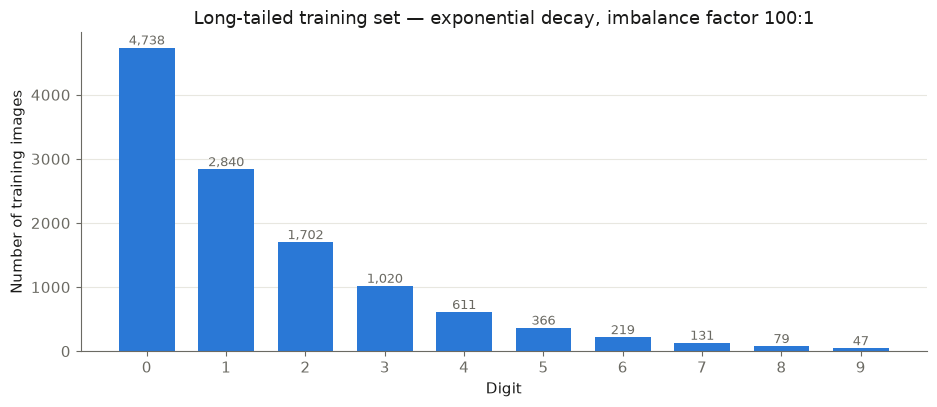

In [8]:
fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.bar(classes, lt_counts, color=BLUE, width=0.7)
for xi, c in zip(classes, lt_counts):
    ax.annotate(f"{c:,}", (xi, c), ha="center", va="bottom", fontsize=9, color=INK_MUTED)
ax.set_xticks(classes)
ax.set_xlabel("Digit")
ax.set_ylabel("Number of training images")
ax.set_title(f"Long-tailed training set — exponential decay, imbalance factor {IMBALANCE_FACTOR}:1")
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

**小結：** 訓練集從 48,000 張縮減為約 11,700 張，且數字 9 只剩 47 張——模型每看到 100 張數字 0，才會看到 1 張數字 9。第 9–11 節將量化這件事對模型的傷害，以及 weighted loss 能挽回多少。

## 6. 資料 Pipeline（transforms 與 DataLoader）

因為我們要用 **ImageNet 預訓練的 ResNet-18 做遷移學習**（第 7 節），輸入格式必須向預訓練模型看齊，落差在資料端解決：

| MNIST 原始格式 | ResNet-18 預期格式 | 我們的適配 |
|------|------|------|
| 28×28 | 224×224（訓練時的解析度）| `Resize` 到 **64×64**：224 是標準做法但計算量是 64 的 12 倍；64×64 已足以讓預訓練 stem（7×7 stride-2 conv + max-pool）正常運作，是準確率與計算成本的折衷 |
| 1 通道灰階 | 3 通道 RGB | `Grayscale(num_output_channels=3)` 把灰階複製成三通道 |
| 像素分布不定 | 以 ImageNet 統計值正規化 | `Normalize(ImageNet mean/std)`——預訓練權重是在這個分布上學的，正規化要一致 |

**資料增強（augmentation）— 只用於訓練集：**

- `RandomAffine`：±10° 旋轉、±10% 平移、0.9–1.1 倍縮放。手寫數字在這些擾動下仍是合法的數字，等於免費擴增了資料的視覺多樣性——對只有幾十張樣本的尾部類別特別重要。
- 刻意**不使用鏡像翻轉**：翻轉會破壞數字語意（例如 2/5、6/9 翻轉後會混淆類別）。

實作上建立同一份底層資料的兩個「視圖」：套用增強的 `mnist_train_aug`（訓練用）與只做確定性轉換的 `mnist_train_eval`（驗證用），再以 `Subset` 依第 4、5 節產生的索引取出對應影像。`make_train_loader()` 每次以固定 seed 重建 shuffle 順序——確保之後兩組實驗看到**完全相同的批次序列**。

In [9]:
IMG_SIZE = 64
IMAGENET_MEAN = (0.485, 0.456, 0.406)   # 預訓練模型使用的 ImageNet 統計值
IMAGENET_STD = (0.229, 0.224, 0.225)

train_tf = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_tf = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# 同一份底層資料、不同 transform 的兩個視圖
mnist_train_aug = datasets.MNIST(root=DATA_DIR, train=True, transform=train_tf)
mnist_train_eval = datasets.MNIST(root=DATA_DIR, train=True, transform=eval_tf)
mnist_test = datasets.MNIST(root=DATA_DIR, train=False, transform=eval_tf)

train_ds = Subset(mnist_train_aug, lt_train_idx)   # 長尾訓練集（含增強）
val_ds = Subset(mnist_train_eval, val_idx)         # 平衡驗證集（無增強）

BATCH_SIZE = 128


def make_train_loader():
    """每次訓練前重建 loader（固定 seed 的 shuffle），確保實驗間批次順序一致。"""
    g = torch.Generator().manual_seed(SEED)
    return DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, generator=g)


val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)
test_loader = DataLoader(mnist_test, batch_size=256, shuffle=False)

xb, yb = next(iter(make_train_loader()))
print(f"train batches/epoch: {len(make_train_loader())} | batch shape: {tuple(xb.shape)}")
print(f"normalize 後的像素範圍：[{xb.min():.2f}, {xb.max():.2f}]")

train batches/epoch: 92 | batch shape: (128, 3, 64, 64)
normalize 後的像素範圍：[-2.12, 2.64]


## 7. 模型設計（Modeling）— ImageNet 預訓練 ResNet-18 遷移學習

我們直接採用 `torchvision.models` 提供的 **ResNet-18（He et al., 2016）**，載入 **ImageNet 預訓練權重**做遷移學習（transfer learning）。

**為什麼選 ResNet？** ResNet 的核心是**殘差連接（skip connection）**：每個 block 學習殘差 $F(x)$，輸出為 $F(x) + x$。這條 identity 捷徑讓梯度能直接回流到淺層，解決了深層網路的退化（degradation）問題，使優化穩定——這是它成為現代 CNN 標準骨幹網路的原因。

**為什麼用預訓練權重（而不是從零訓練）？**

- CNN 淺層學到的特徵（邊緣、筆畫、紋理方向）是跨領域通用的——ImageNet 上學會的低階視覺特徵可以直接搬到手寫數字。
- 遷移學習在**資料稀少時價值最大**：我們的長尾訓練集只有約 1.2 萬張、尾部類別只有 47 張。從零訓練時這 47 張要獨力撐起所有特徵學習；有預訓練權重時，模型只需要學會「把已有的視覺特徵組合成數字類別」，等於一個很強的先驗（prior）與正則化。
- 這也是業界處理小樣本影像任務的標準第一選擇：先遷移學習，不夠再考慮客製架構。

**需要適配的只有兩端：**

| 位置 | 落差 | 解法 |
|------|------|------|
| 輸入端 | 1 通道 28×28 vs. 3 通道高解析 | 已在第 6 節的資料 pipeline 解決（resize 64、三通道化、ImageNet 正規化）——模型本體完全不動 |
| 輸出端 | ImageNet 1000 類 vs. MNIST 10 類 | 把最後的全連接層 `fc` 換成新的 `Linear(512, 10)`（隨機初始化） |

模型其餘 11.2M 個參數全部載入預訓練權重，微調策略（哪些層用多大的學習率）在第 8 節說明。

In [10]:
from torchvision.models import ResNet18_Weights, resnet18


def make_transfer_model():
    """載入 ImageNet 預訓練的 ResNet-18，把分類頭換成 10 類。"""
    model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, 10)
    return model


# 架構健全性檢查：參數量與輸出形狀
_m = make_transfer_model()
n_params = sum(p.numel() for p in _m.parameters())
n_head = sum(p.numel() for p in _m.fc.parameters())
out = _m(torch.randn(2, 3, IMG_SIZE, IMG_SIZE))
print(f"總參數量：{n_params:,}（其中新分類頭佔 {n_head:,}，其餘皆為 ImageNet 預訓練權重）")
print(f"輸入 (2, 3, {IMG_SIZE}, {IMG_SIZE}) → 輸出 {tuple(out.shape)}")
del _m, out

總參數量：11,181,642（其中新分類頭佔 5,130，其餘皆為 ImageNet 預訓練權重）
輸入 (2, 3, 64, 64) → 輸出 (2, 10)


## 8. 訓練與優化策略（Optimization）

**微調（fine-tuning）策略：全網微調 + 差異化學習率（discriminative learning rates）**

遷移學習有兩種常見做法：(1) 凍結 backbone 只訓練分類頭（feature extraction），(2) 全網微調。ImageNet（自然彩色照片）與 MNIST（手寫筆畫）的領域差距不小，凍結 backbone 會限制特徵適應目標領域，因此我們選擇**全網微調**，但給不同部位不同的學習率：

- **Backbone（預訓練層）lr = 1e-4**：權重已經很好，只需小步修正。學習率太大會把預訓練特徵洗掉（災難性遺忘，catastrophic forgetting）。
- **新分類頭 `fc` lr = 1e-3**：隨機初始化、需要從頭學，用 10 倍大的學習率。

| 設定 | 選擇 | 理由 |
|------|------|------|
| Optimizer | AdamW（backbone lr=1e-4 / head lr=1e-3，weight decay=1e-4）| 自適應學習率收斂快；decoupled weight decay 讓正則化不與梯度縮放耦合 |
| LR scheduler | CosineAnnealingLR | 兩組學習率同步平滑衰減至近 0：前期大步探索、後期小步收斂 |
| Early stopping | patience=4，監控 **validation macro-F1** | 防止過擬合，只保留最佳權重 |
| Batch size | 128 | 訓練速度與梯度雜訊的折衷 |
| Epoch 上限 | 20 | 搭配 early stopping，通常會提前收斂 |

兩個關鍵細節：

- **用 macro-F1（而非 accuracy）做模型選擇。** 在類別不平衡的情境下，accuracy 會被頭部類別主導——一個完全放棄尾部類別的模型仍可能拿到不錯的 accuracy。macro-F1 對每個類別一視同仁（先算每類 F1 再平均），尾部類別的崩壞會立刻反映在指標上。
- **Validation loss 一律用未加權的 cross-entropy 計算**（weighted 實驗也一樣），兩組實驗的驗證曲線才有相同量尺、可以直接比較。

`train_model()` 在建立模型前重設隨機種子、並重建 DataLoader，因此兩組實驗從**相同的初始權重（同一份預訓練權重 + 相同初始化的分類頭）、相同的批次順序**出發——唯一的變因只有 loss function，符合控制變因的實驗設計。

In [11]:
plain_ce = nn.CrossEntropyLoss()   # 驗證 loss 一律用未加權 CE，跨實驗可比


def evaluate(model, loader):
    """回傳 (平均 loss, accuracy, macro-F1, y_true, y_pred)。"""
    model.eval()
    total_loss, preds, targets = 0.0, [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            total_loss += plain_ce(logits, yb).item() * len(xb)
            preds.append(logits.argmax(1).cpu())
            targets.append(yb.cpu())
    y_pred = torch.cat(preds).numpy()
    y_true = torch.cat(targets).numpy()
    return (total_loss / len(y_true), (y_pred == y_true).mean(),
            f1_score(y_true, y_pred, average="macro"), y_true, y_pred)


def train_model(criterion, tag, max_epochs=20, patience=4,
                lr_backbone=1e-4, lr_head=1e-3, weight_decay=1e-4):
    """微調一個預訓練 ResNet-18，回傳 (最佳模型, 訓練歷程)。"""
    torch.manual_seed(SEED)                      # 兩組實驗使用相同的初始權重與增強序列
    model = make_transfer_model().to(device)

    # 差異化學習率：預訓練 backbone 小步微調、新分類頭大步學習
    backbone_params = [p for n, p in model.named_parameters() if not n.startswith("fc.")]
    optimizer = torch.optim.AdamW([
        {"params": backbone_params, "lr": lr_backbone},
        {"params": model.fc.parameters(), "lr": lr_head},
    ], weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)
    train_loader = make_train_loader()           # 重建 loader，批次順序也一致

    history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_macro_f1": []}
    best = {"f1": -1.0, "epoch": 0, "state": None}

    for epoch in range(1, max_epochs + 1):
        model.train()
        running = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            running += loss.item() * len(xb)
        scheduler.step()

        train_loss = running / len(train_loader.dataset)
        val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_macro_f1"].append(val_f1)

        marker = ""
        if val_f1 > best["f1"]:
            best.update(f1=val_f1, epoch=epoch,
                        state={k: v.detach().cpu().clone()
                               for k, v in model.state_dict().items()})
            marker = "  <- best"
        print(f"[{tag}] epoch {epoch:2d} | train loss {train_loss:.4f} | "
              f"val loss {val_loss:.4f} | val acc {val_acc:.4f} | "
              f"val macro-F1 {val_f1:.4f}{marker}")

        if epoch - best["epoch"] >= patience:
            print(f"[{tag}] early stopping：val macro-F1 已連續 {patience} 個 epoch 未提升")
            break

    model.load_state_dict(best["state"])
    print(f"[{tag}] 最佳 epoch = {best['epoch']} | val macro-F1 = {best['f1']:.4f}\n")
    return model, history

## 9. 實驗一：Baseline — 一般 Cross-Entropy

不做任何不平衡處理，直接在長尾訓練集上以標準 cross-entropy 訓練。預期行為：loss 由頭部類別主導，模型缺乏動機學好只佔訓練集 0.4% 的尾部類別——這就是我們要量化的「問題」。

In [12]:
baseline_model, hist_base = train_model(nn.CrossEntropyLoss(), tag="baseline")

[baseline] epoch  1 | train loss 0.2602 | val loss 0.1525 | val acc 0.9581 | val macro-F1 0.9575  <- best


[baseline] epoch  2 | train loss 0.0485 | val loss 0.1445 | val acc 0.9568 | val macro-F1 0.9565


[baseline] epoch  3 | train loss 0.0323 | val loss 0.0987 | val acc 0.9713 | val macro-F1 0.9712  <- best


[baseline] epoch  4 | train loss 0.0240 | val loss 0.1218 | val acc 0.9675 | val macro-F1 0.9672


[baseline] epoch  5 | train loss 0.0176 | val loss 0.1122 | val acc 0.9705 | val macro-F1 0.9702


...

[baseline] epoch 10 | train loss 0.0046 | val loss 0.0739 | val acc 0.9817 | val macro-F1 0.9816  <- best


[baseline] epoch 11 | train loss 0.0062 | val loss 0.0747 | val acc 0.9815 | val macro-F1 0.9815


[baseline] epoch 12 | train loss 0.0042 | val loss 0.0880 | val acc 0.9794 | val macro-F1 0.9793


[baseline] epoch 13 | train loss 0.0038 | val loss 0.0919 | val acc 0.9779 | val macro-F1 0.9778


[baseline] epoch 14 | train loss 0.0033 | val loss 0.0883 | val acc 0.9784 | val macro-F1 0.9785
[baseline] early stopping：val macro-F1 已連續 4 個 epoch 未提升
[baseline] 最佳 epoch = 10 | val macro-F1 = 0.9816



## 10. 實驗二：Weighted Cross-Entropy

處理手法：給每個類別的 loss 乘上與樣本數**成反比**的權重（inverse-frequency weighting）：

$$w_c = \frac{N}{K \cdot n_c}$$

其中 $N$ 為訓練集總樣本數、$K=10$ 為類別數、$n_c$ 為類別 $c$ 的樣本數（實作上再正規化到平均為 1）。直觀效果：一張尾部影像對梯度的貢獻被放大——數字 9 的單張權重約為數字 0 的 100 倍，等於在期望值上讓每個類別對總 loss 的貢獻相等，模型不再能靠「放棄尾部」來降低 loss。

**替代方案的取捨**（本 notebook 不實作，僅供設計比較）：

- **Oversampling / `WeightedRandomSampler`**：讓每個 batch 的類別組成均勻。期望上與 loss 加權等價，但重複取樣尾部影像較容易過擬合（需搭配增強緩解）。
- **Focal Loss**（Lin et al., 2017）：以 $(1-p_t)^\gamma$ 動態降低「已學會」樣本的權重，把梯度集中在困難樣本，常用於物件偵測的極端不平衡。
- **Logit adjustment / 兩階段訓練（decoupling）**：先在原始分布學表徵、再校正分類器，是近年長尾學習文獻的主流方向。

In [13]:
n_c = torch.tensor(lt_counts, dtype=torch.float32)
class_weights = len(train_ds) / (10 * n_c)
class_weights = class_weights / class_weights.mean()   # 正規化到平均 = 1

display(pd.DataFrame({
    "n_train": lt_counts,
    "weight": class_weights.numpy().round(3),
}, index=pd.Index(classes, name="digit")))

weighted_ce = nn.CrossEntropyLoss(weight=class_weights.to(device))
weighted_model, hist_weighted = train_model(weighted_ce, tag="weighted")

,n_train,weight
digit,,
0,4738,0.040
1,2840,0.067
2,1702,0.112
3,1020,0.186
4,611,0.311
5,366,0.519
6,219,0.868
7,131,1.450
8,79,2.405


[weighted] epoch  1 | train loss 0.7118 | val loss 0.1481 | val acc 0.9542 | val macro-F1 0.9540  <- best


[weighted] epoch  2 | train loss 0.1651 | val loss 0.1453 | val acc 0.9631 | val macro-F1 0.9632  <- best


[weighted] epoch  3 | train loss 0.1566 | val loss 0.0956 | val acc 0.9739 | val macro-F1 0.9737  <- best


[weighted] epoch  4 | train loss 0.0699 | val loss 0.0805 | val acc 0.9768 | val macro-F1 0.9766  <- best


...

[weighted] epoch 10 | train loss 0.0249 | val loss 0.0590 | val acc 0.9848 | val macro-F1 0.9846  <- best


[weighted] epoch 11 | train loss 0.0246 | val loss 0.0599 | val acc 0.9845 | val macro-F1 0.9844


[weighted] epoch 12 | train loss 0.0256 | val loss 0.0684 | val acc 0.9817 | val macro-F1 0.9815


[weighted] epoch 13 | train loss 0.0148 | val loss 0.0642 | val acc 0.9833 | val macro-F1 0.9832


[weighted] epoch 14 | train loss 0.0201 | val loss 0.0603 | val acc 0.9844 | val macro-F1 0.9843
[weighted] early stopping：val macro-F1 已連續 4 個 epoch 未提升
[weighted] 最佳 epoch = 10 | val macro-F1 = 0.9846



## 11. 成果評估與對比

所有評估都在**平衡的官方 test set（10,000 張，模型從未見過）**上進行，依序呈現：

1. 整體指標與 per-class F1 對照表
2. 訓練曲線（loss 與 validation macro-F1）
3. Confusion matrix（列正規化）對比
4. Per-class F1 長條圖對比
5. 尾部類別（7 / 8 / 9）的 Precision–Recall 曲線
6. 被 weighted loss「救回」的測試影像實例

In [14]:
def predict_probs(model, loader):
    """回傳 (softmax 機率矩陣 [N, 10], 真實標籤 [N])。"""
    model.eval()
    logits_all, targets = [], []
    with torch.no_grad():
        for xb, yb in loader:
            logits_all.append(model(xb.to(device)).cpu())
            targets.append(yb)
    probs = F.softmax(torch.cat(logits_all), dim=1).numpy()
    return probs, torch.cat(targets).numpy()


probs_base, y_test_true = predict_probs(baseline_model, test_loader)
probs_wt, _ = predict_probs(weighted_model, test_loader)
pred_base = probs_base.argmax(1)
pred_wt = probs_wt.argmax(1)

# --- 整體指標 -----------------------------------------------------------------
summary = pd.DataFrame({
    "accuracy": [(pred_base == y_test_true).mean(), (pred_wt == y_test_true).mean()],
    "balanced_accuracy": [balanced_accuracy_score(y_test_true, pred_base),
                          balanced_accuracy_score(y_test_true, pred_wt)],
    "macro_F1": [f1_score(y_test_true, pred_base, average="macro"),
                 f1_score(y_test_true, pred_wt, average="macro")],
}, index=["Baseline (CE)", "Weighted CE"]).round(4)
display(summary)

# --- Per-class F1 --------------------------------------------------------------
f1_base = f1_score(y_test_true, pred_base, average=None)
f1_wt = f1_score(y_test_true, pred_wt, average=None)
per_class = pd.DataFrame({
    "n_train": lt_counts,
    "F1_baseline": f1_base.round(4),
    "F1_weighted": f1_wt.round(4),
    "F1_gain": (f1_wt - f1_base).round(4),
}, index=pd.Index(classes, name="digit"))
display(per_class)

,accuracy,balanced_accuracy,macro_F1
Baseline (CE),0.9819,0.9817,0.9819
Weighted CE,0.9838,0.9835,0.9836


,n_train,F1_baseline,F1_weighted,F1_gain
digit,,,,
0,4738,0.9904,0.9939,0.0035
1,2840,0.9874,0.9939,0.0065
2,1702,0.9800,0.9884,0.0084
3,1020,0.9854,0.9790,-0.0063
4,611,0.9868,0.9847,-0.0021
5,366,0.9865,0.9831,-0.0034
6,219,0.9795,0.9848,0.0053
7,131,0.9747,0.9863,0.0116
8,79,0.9792,0.9760,-0.0032


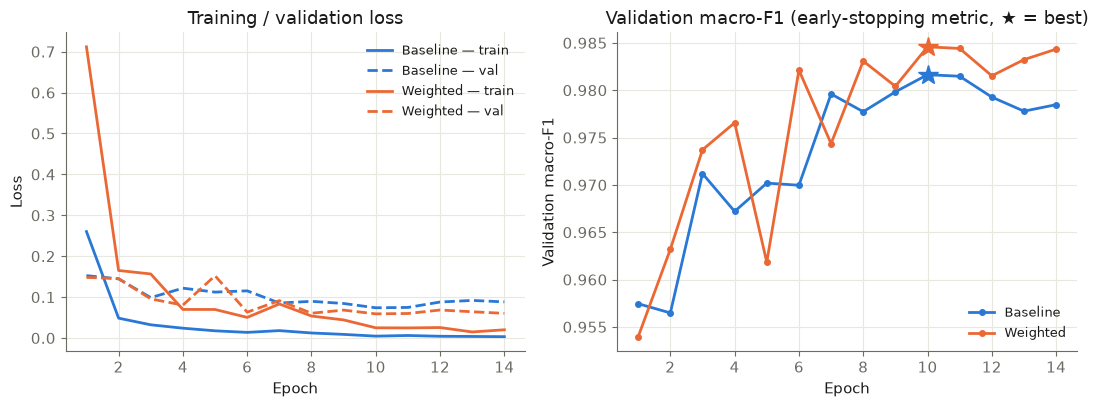

In [15]:
# --- 訓練曲線 -------------------------------------------------------------------
# 注意：左圖中 weighted 實驗的 train loss 是「加權後」的值，量級與 baseline 不同，
# 看趨勢即可；val loss 一律為未加權 CE，兩組可直接比較。
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

ep_b = np.arange(1, len(hist_base["train_loss"]) + 1)
ep_w = np.arange(1, len(hist_weighted["train_loss"]) + 1)

ax = axes[0]
ax.plot(ep_b, hist_base["train_loss"], color=BLUE, lw=2, label="Baseline — train")
ax.plot(ep_b, hist_base["val_loss"], color=BLUE, lw=2, ls="--", label="Baseline — val")
ax.plot(ep_w, hist_weighted["train_loss"], color=ORANGE, lw=2, label="Weighted — train")
ax.plot(ep_w, hist_weighted["val_loss"], color=ORANGE, lw=2, ls="--", label="Weighted — val")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training / validation loss")
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
for hist, color, name in [(hist_base, BLUE, "Baseline"), (hist_weighted, ORANGE, "Weighted")]:
    f1s = hist["val_macro_f1"]
    ep = np.arange(1, len(f1s) + 1)
    ax.plot(ep, f1s, color=color, lw=2, marker="o", ms=4, label=name)
    best_ep = int(np.argmax(f1s)) + 1
    ax.plot(best_ep, max(f1s), marker="*", ms=15, color=color)
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation macro-F1")
ax.set_title("Validation macro-F1 (early-stopping metric, ★ = best)")
ax.legend(frameon=False, fontsize=9, loc="lower right")

fig.tight_layout()
plt.show()

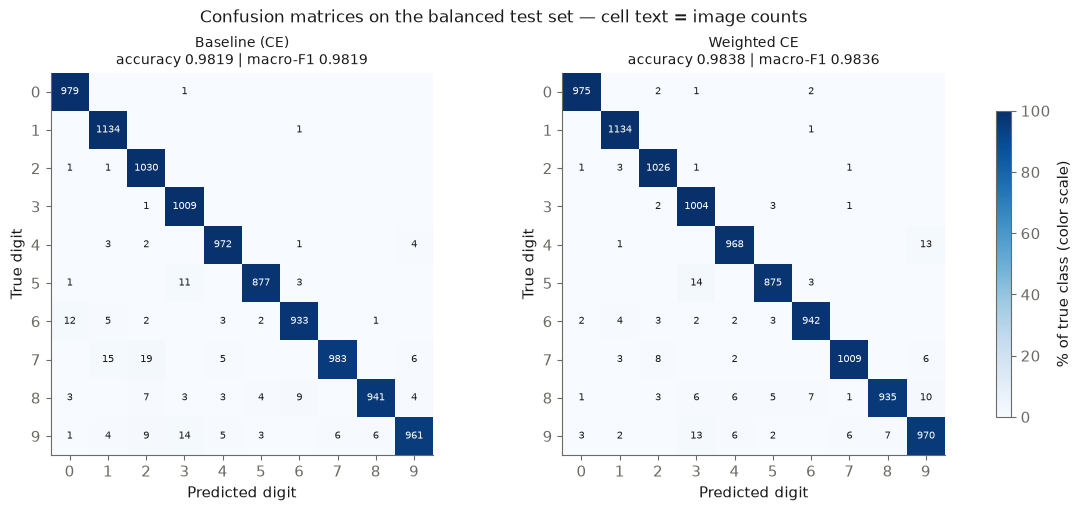

In [16]:
# --- Confusion matrices（顏色 = 列正規化 %，格內數字 = 實際張數）--------------------
# 兩張圖評估的是同一份 test set，因此每一列的張數加總完全相同（= 該數字的測試張數）。
fig, axes = plt.subplots(1, 2, figsize=(11.5, 5), layout="constrained")
for ax, (name, pred) in zip(axes, [("Baseline (CE)", pred_base), ("Weighted CE", pred_wt)]):
    counts = confusion_matrix(y_test_true, pred)                   # 實際張數
    cm_pct = counts / counts.sum(axis=1, keepdims=True) * 100      # 列正規化（僅用於上色）
    im = ax.imshow(cm_pct, cmap="Blues", vmin=0, vmax=100)
    for i in range(10):
        for j in range(10):
            if counts[i, j] > 0:
                ax.text(j, i, f"{counts[i, j]}", ha="center", va="center", fontsize=7,
                        color="white" if cm_pct[i, j] > 60 else INK)
    acc = (pred == y_test_true).mean()
    mf1 = f1_score(y_test_true, pred, average="macro")
    ax.set_title(f"{name}\naccuracy {acc:.4f} | macro-F1 {mf1:.4f}", fontsize=10)
    ax.set_xlabel("Predicted digit")
    ax.set_ylabel("True digit")
    ax.set_xticks(classes)
    ax.set_yticks(classes)
    ax.grid(False)
fig.colorbar(im, ax=axes, shrink=0.8, label="% of true class (color scale)")
fig.suptitle("Confusion matrices on the balanced test set — cell text = image counts",
             fontsize=12)
plt.show()

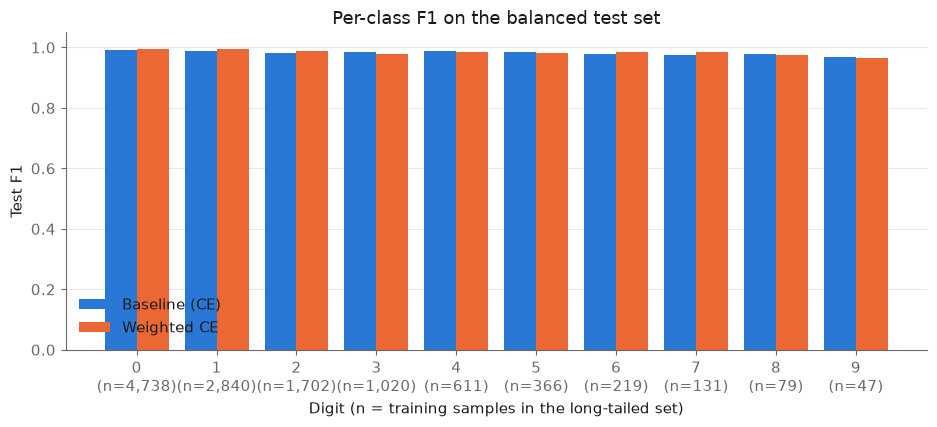

In [17]:
# --- Per-class F1 對比 -----------------------------------------------------------
x = np.arange(10)
w = 0.4
fig, ax = plt.subplots(figsize=(9.5, 4.4))
ax.bar(x - w / 2, f1_base, width=w, color=BLUE, label="Baseline (CE)")
ax.bar(x + w / 2, f1_wt, width=w, color=ORANGE, label="Weighted CE")
ax.set_xticks(x, [f"{c}\n(n={n:,})" for c, n in zip(classes, lt_counts)])
ax.set_ylim(0, 1.05)
ax.set_xlabel("Digit (n = training samples in the long-tailed set)")
ax.set_ylabel("Test F1")
ax.set_title("Per-class F1 on the balanced test set")
ax.legend(frameon=False, loc="lower left")
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

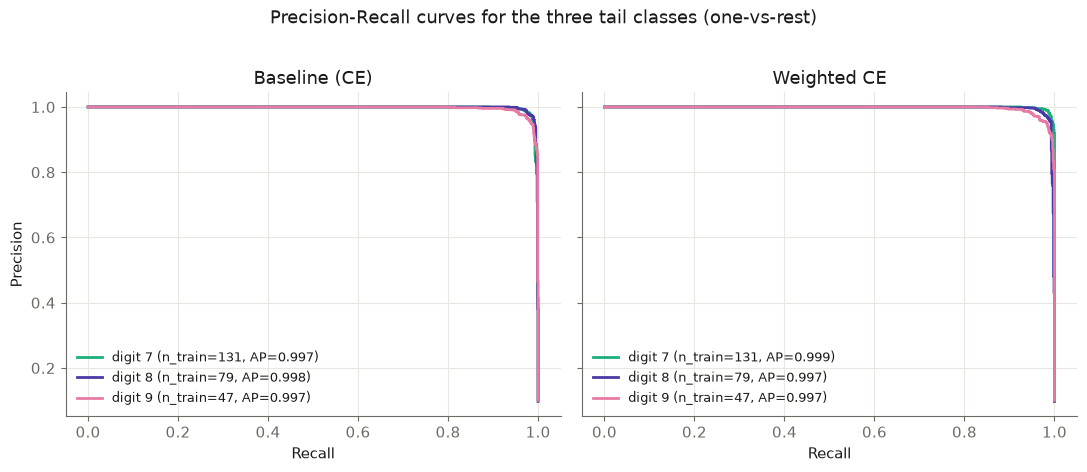

In [18]:
# --- 尾部類別的 Precision–Recall 曲線（one-vs-rest）--------------------------------
TAIL = [7, 8, 9]
tail_colors = {7: AQUA, 8: VIOLET, 9: MAGENTA}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), sharey=True)
for ax, (name, probs) in zip(axes, [("Baseline (CE)", probs_base), ("Weighted CE", probs_wt)]):
    for c in TAIL:
        y_bin = (y_test_true == c).astype(int)
        prec, rec, _ = precision_recall_curve(y_bin, probs[:, c])
        ap = average_precision_score(y_bin, probs[:, c])
        ax.plot(rec, prec, lw=2, color=tail_colors[c],
                label=f"digit {c} (n_train={lt_counts[c]}, AP={ap:.3f})")
    ax.set_xlabel("Recall")
    ax.set_title(name)
    ax.legend(frameon=False, fontsize=9, loc="lower left")
axes[0].set_ylabel("Precision")
fig.suptitle("Precision-Recall curves for the three tail classes (one-vs-rest)", y=1.02)
fig.tight_layout()
plt.show()

尾部類別（7/8/9）中，baseline 分錯而 weighted 分對的測試影像共 62 張


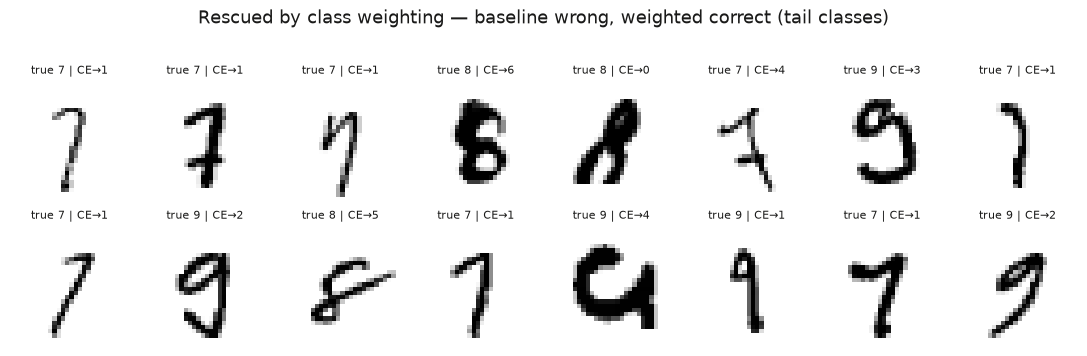

In [19]:
# --- 被 weighted loss「救回」的測試影像：baseline 分錯、weighted 分對（尾部類別）----
rescued = np.where((pred_base != y_test_true) & (pred_wt == y_test_true)
                   & (y_test_true >= 7))[0]
print(f"尾部類別（7/8/9）中，baseline 分錯而 weighted 分對的測試影像共 {len(rescued)} 張")

show = rescued[:16]
fig, axes = plt.subplots(2, 8, figsize=(11, 3.6))
for ax in axes.ravel():
    ax.set_axis_off()
for ax, i in zip(axes.ravel(), show):
    ax.imshow(mnist_test.data[i], cmap="gray_r")
    ax.set_title(f"true {y_test_true[i]} | CE→{pred_base[i]}", fontsize=8, color=INK)
fig.suptitle("Rescued by class weighting — baseline wrong, weighted correct (tail classes)",
             y=1.02)
fig.tight_layout()
plt.show()